# Assignment 1

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:

    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).
---

### Import libraries

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

### Define functions

In [ ]:
def create_1d_data(num_examples, w, b, bound):
  """Create X, Y data with a linear relationship with added noise.

  Args:
    num_examples: number of examples to generate
    w: desired slope
    b: desired intercept
    bound: lower and upper boundary of the data interval

  Returns:
    X and Y with shape (num_examples)
  """
  np.random.seed(4)  # consistent random number generation
  X = np.arange(num_examples)
  deltas = np.random.uniform(low=-bound, high=bound, size=X.shape) # added noise
  Y = b + deltas + w * X

  return X, Y

---
### Step 1: Data ingestion

Supervised learning is all about learning to make predictions: given an input $x$ (e.g. home square footage), can we produce an output $\hat{y}$ (e.g. estimated value) as close to the actual observed output $y$ (e.g. sale price) as possible. Note that the "hat" above $y$ is used to denote an estimated or predicted value.

Let's start by generating some artificial data. We'll create a vector of inputs, $X$, and a corresponding vector of target outputs $Y$. In general, we'll refer to invidual examples with a lowercase ($x$), and a vector or matrix containing multiple examples with a capital ($X$).

### <span style="color:chocolate">Exercise 1:</span> Create data (10 points)

Create artificial data using the function <span style="color:chocolate">create_1d_data()</span> defined at the top of this notebook. Set the following argument values:
- number of examples = 70;
- slope (w) = 2;
- intercept (b) = 1;
- bound = 1.

Denote the output by X and Y. Print the shape and the first 10 elements for each object.

In [5]:
X, Y = create_1d_data(num_examples=70, w=2, b=1, bound=1)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("First 10 elements of X:", X[:10])
print("First 10 elements of Y:", Y[:10])

X shape: (70,)
Y shape: (70,)
First 10 elements of X: [0 1 2 3 4 5 6 7 8 9]
First 10 elements of Y: [ 1.93405968  3.0944645   5.94536872  7.42963199  9.39545765 10.43217899
 13.95254891 14.01246051 16.50596472 18.86958306]


---
### Step 2: Data preprocessing

Given the simplicity of the data (just one feature in X), our sole task here is to divide the data into training and test sets.

### <span style="color:chocolate">Exercise 2:</span> Data splits (10 points)

Using the <span style="color:chocolate">train_test_split()</span> method available in scikit-learn:
1. Split the (X,Y) data into training and test paritions by setting test_size=0.3 and random_state=1234. All the other arguments of the method are set to default values. Name the resulting arrays X_train, X_test, Y_train, Y_test;
2. Print the shape of each array.

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=1234)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (49,)
X_test shape: (21,)
Y_train shape: (49,)
Y_test shape: (21,)


---
### Step 3: Exploratory data analysis (EDA)

EDA helps us to gain insights into the distribution and characteristics of the dataset we are dealing with. 
This understanding is fundamental for making informed decisions regarding:
- data cleaning;
- feature selection;
- model building;
- model evaluation, etc.

### <span style="color:chocolate">Exercise 3:</span> Plots (10 points)

1. Generate a scatter plot displaying the X_train data along the x-axis and the Y_train data along the y-axis, ensuring clear labeling of both axes. Add a title "Exploratory Data Analysis: Training Data" and a legend "observed training data" to the plot;
2. Enhance the plot by incorporating a vertical red line to denote the mean value of X_train. Accompany it with a legend clarifying the meaning of the line and the mean value of X_train.

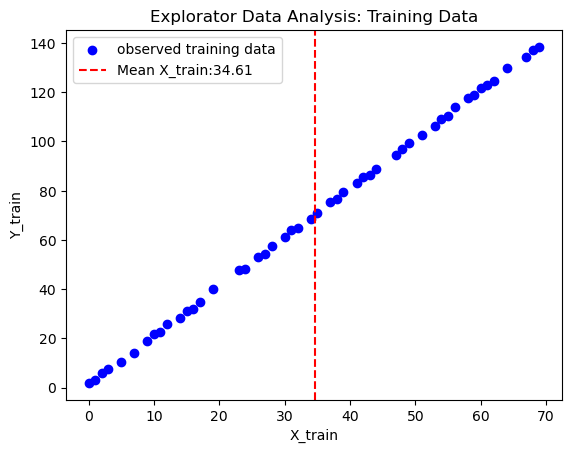

In [9]:
#scatter plot
plt.scatter(X_train, Y_train, color="blue", label="observed training data")
plt.title("Explorator Data Analysis: Training Data")
plt.xlabel("X_train")
plt.ylabel("Y_train")

#vertical line
x_train_mean = X_train.mean()
plt.axvline(x=x_train_mean, color="red", linestyle="--", label=f"Mean X_train:{x_train_mean:.2f}")

plt.legend()
plt.show()


---
### Step 4: Modeling

In this section, our objective is to propose models to describe the data generation process. Remember a model is a function that takes an input $x$ and produces a prediction $\hat{y}$.

Let's consider two possible models for this data:
1. $M_1(x) = 5+x$ 
2. $M_2(x) = 1+2x$

### <span style="color:chocolate">Exercise 4:</span> Models for data (10 points)

1. Compute the predictions of models $M_1$ and $M_2$ for the values in X_train. These predictions should be vectors of the same shape as Y_train. Call these predictions M1_hat_train and M2_hat_train. Hint: the "learned" parameters are alredy provided to you;
2. Plot the prediction lines of these two models overlayed on the observed data (X_train, Y_train). Note: you will generate only one plot. Make sure to include axes names, titles and legend. 

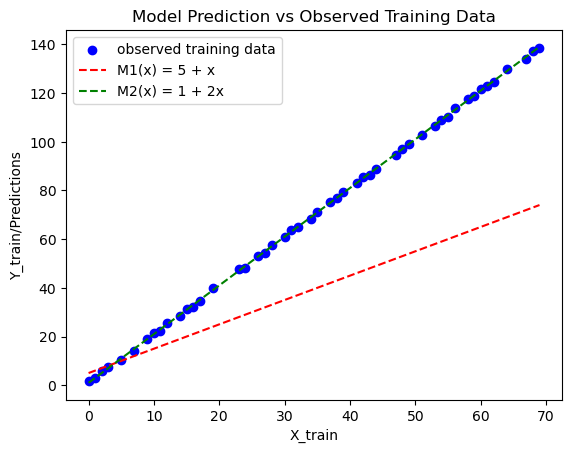

In [11]:
M1_hat_train = 5 + X_train
M2_hat_train = 1+ 2*X_train

plt.scatter(X_train, Y_train, color="blue", label="observed training data")
sort_idx = np.argsort(X_train)
plt.plot(X_train[sort_idx], M1_hat_train[sort_idx], color="red", linestyle = "--", label="M1(x) = 5 + x")
plt.plot(X_train[sort_idx], M2_hat_train[sort_idx], color="green", linestyle = "--", label="M2(x) = 1 + 2x")

plt.title("Model Prediction vs Observed Training Data")
plt.xlabel("X_train")
plt.ylabel("Y_train/Predictions")

plt.legend()
plt.show()

---
### Step 5: Evaluation and Generalization

How good are our models? Intuitively, the better the model, the more closely it fits the data we have. That is, for each $x$, we'll compare $y$, the true value, with $\hat{y}$, the predicted value. This comparison is often called the *loss* or the *error*. One common such comparison is *squared error*: $(y-\hat{y})^2$. Averaging over all our data points, we get the *mean squared error*:

\begin{equation}
\textit{MSE} = \frac{1}{n} \sum_{y_i \in Y}(y_i - \hat{y}_i)^2
\end{equation}

How well do our models generalize? The test dataset serves as a proxy for unseen data in real-world applications. By evaluating the model on the test data, you can assess its ability to generalize beyond the training data. This ensures that the model can make accurate predictions on new data it hasn't seen during training.

### <span style="color:chocolate">Exercise 5:</span> Computing MSE (20 points)

1. Write a function for computing the MSE metric based on the provided definition;
2. Utilizing this function, calculate the training data MSE for the two models, $M_1$ and $M_2$.
3. Comment on which model fits the training data better.

In [13]:
# YOUR CODE HERE
def MSE(true_values, predicted_values):
  """Return the MSE between true_values and predicted values."""
  return np.mean((true_values - predicted_values) ** 2)

mse_m1 = MSE(Y_train, M1_hat_train)
mse_m2 = MSE(Y_train, M2_hat_train)
print("M1 training MSE:", mse_m1)
print("M2 training MSE:", mse_m2)

M1 training MSE: 1358.2515152570322
M2 training MSE: 0.31356845204652894


In [14]:
# YOUR CODE HERE
"""Model 2(M2) fits the training data better than M1.  
This is because MSE measures the average squred distance between the actual data points and the model's predictions. 
A lower MSE indicates a tighter, more accurate fit. 
M2's MSE 0.31356845204652894 is less than M1's MSE 1358.2515152570322. From the scatter plot, M2's slop also overlayed with ovserved training data slop.
"""

"Model 2(M2) fits the training data better than M1.  \nThis is because MSE measures the average squred distance between the actual data points and the model's predictions. \nA lower MSE indicates a tighter, more accurate fit. \nM2's MSE 0.31356845204652894 is less than M1's MSE 1358.2515152570322. From the scatter plot, M2's slop also overlayed with ovserved training data slop.\n"

### <span style="color:chocolate">Exercise 6:</span> Generalization (15 points)

1. Compute the predictions of models $M_1$ and $M_2$ for the values in X_test. These predictions should be vectors of the same shape as Y_test. Call these predictions M1_hat_test and M2_hat_test.
2. Calculate the test data MSE for the two models, $M_1$ and $M_2$, using the <span style="color:chocolate">MSE()</span> function defined above.
3. Does the model you chose in Exercise 5 generalize well? Hint: compare training and test MSE.

In [17]:
# YOUR CODE HERE
M1_hat_test = 5 + X_test
M2_hat_test = 1 + 2 * X_test
mse_m1_test = MSE(Y_test, M1_hat_test)
mse_m2_test = MSE(Y_test, M2_hat_test)
print("M1 test MSE:", mse_m1_test)
print("M2 test MSE:", mse_m2_test)

# Does the model you chose in Exercise 5 generalizae well
"""
Yes, Model 2 (M2) generalizes well. 
The training data MSE is 0.31356845204652894 and the test data MSE is 0.3370228107719305. 
These 2 values are extremely cose and low. It confirmes that Model 2 did not overfit to the training set.
"""

M1 test MSE: 1300.1040149275498
M2 test MSE: 0.3370228107719305


'\nYes, Model 2 (M2) generalizes well. \nThe training data MSE is 0.31356845204652894 and the test data MSE is 0.3370228107719305. \nThese 2 values are extremely cose and low. It confirmes that Model 2 did not overfit to the training set.\n'

### <span style="color:chocolate">Exercise 7:</span> More features (25 points)

1. Fit an 8-th degree polynomial to (X_train, Y_train). Call the predictions of this model M3_hat_train. Hint: see <span style="color:chocolate">np.polyfit()</span> for details.
2. Plot the prediction lines of the $M_3$ overlayed on the observed data (X_train, Y_train). Note: you will generate only one plot. Make sure to include axes names, titles and legend. 
3. Calculate the training data MSE for the $M_3$ model using the <span style="color:chocolate">MSE()</span> function defined above.
4. Does model $M_3$ do better than your chosen model in Exercise 5 at predicting the labels for new unseen data? Hint: your new unseen data is the test dataset; compare training and test MSE.

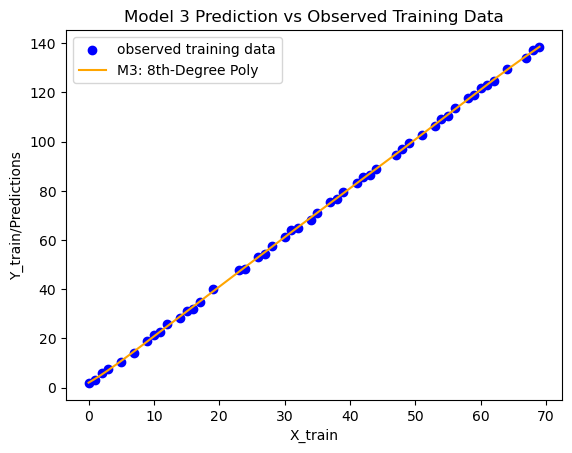

M3 training MSE: 0.26588964117463315
M3 test MSE: 0.39682610650677846


"\nNo. M3 doesn't do better than M2 at predicting new unseen data.\nM3 has a lower training MSE 0.26588964117463315 than M2 0.31356845204652894 because an 8th degree polinominal has complex flexibility. \n\ncomparing the test data MSE, M3 test data MSE 0.39682610650677846 is larger than M2 test data MSE 0.3370228107719305 indecates \nthe performance degrades.\nTherefore, M3 is overfitted. M2 is the better model.\n"

In [23]:
# YOUR CODE HERE
# 1. Fit an 8-th degree polynominal
coefficients = np.polyfit(X_train, Y_train, deg=8)
M3 = np.poly1d(coefficients)
M3_hat_train = M3(X_train)

# 2. Plot prediction lines of the M3
plt.scatter(X_train, Y_train, color="blue", label="observed training data")
X_line = np.linspace(X_train.min(), X_train.max(), 500)
plt.plot(X_line, M3(X_line), color="orange", linestyle = "-", label="M3: 8th-Degree Poly")

plt.title("Model 3 Prediction vs Observed Training Data")
plt.xlabel("X_train")
plt.ylabel("Y_train/Predictions")

plt.legend()
plt.show()

#3. calculate the training data MSE for M3
mse_m3_train = MSE(Y_train, M3_hat_train)
print("M3 training MSE:", mse_m3_train)

#4. Does the M3 better than the chosen model in Excersice 5
M3_hat_test = M3(X_test)
mse_m3_test = MSE(Y_test, M3_hat_test)
print("M3 test MSE:", mse_m3_test)

"""
No. M3 doesn't do better than M2 at predicting new unseen data.
M3 has a lower training MSE 0.26588964117463315 than M2 0.31356845204652894 because an 8th degree polinominal has complex flexibility. 

comparing the test data MSE, M3 test data MSE 0.39682610650677846 is larger than M2 test data MSE 0.3370228107719305 indecates 
the performance degrades.
Therefore, M3 is overfitted. M2 is the better model.
"""



----
### <span style="color:chocolate"></span> Additional practice (not graded)

Would you perform EDA on the test dataset?
1. Why or why not?
2. Provide a link to a paper/article to support your answer.

In [ ]:
# YOUR ANSWER HERE